C:\Users\sahad2\AppData\Local\Temp\ipykernel_9544\2652655338.py:93: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  flooded.plot(ax=ax, color='black', marker='o', markersize=6, alpha=0.5, zorder=5)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_9544\2652655338.py:94: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  dry.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_9544\2652655338.py:93: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  flooded.plot(ax=ax, color='black', marker='o', markersize=6, alpha=0.5, zorder=5)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_9544\2652655338.py:94: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  dry.plot(ax=ax, color='grey', marker='o', markersize=5, zorder=5)


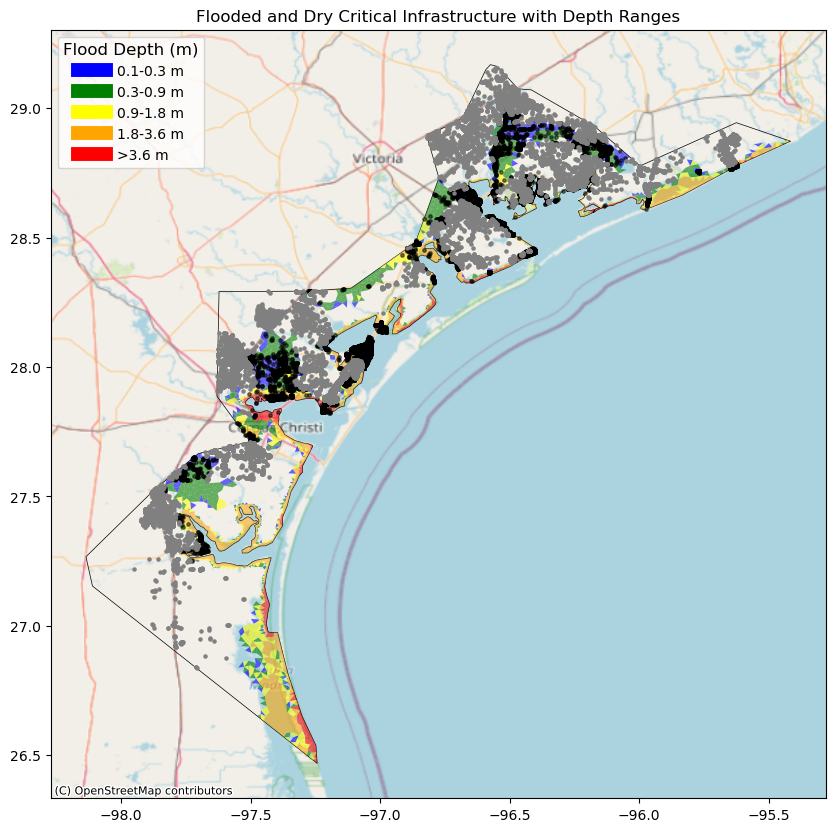

In [5]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\5-yr return period storm CC.m21fm - Result Files\5-yr_CC_stat_coupled.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth")

# Load the shapefile for the land boundary
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)

# Load infrastructure shapefiles and set CRS (EPSG:32614)
infrastructure_paths = [
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48007_ap\shp\stratmap24-addresspoints_48007_aransas_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48057_ap\shp\stratmap24-addresspoints_48057_calhoun_202402.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48239_ap\shp\stratmap24-addresspoints_48239_jackson_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48321_ap\shp\stratmap24-addresspoints_48321_matagorda_202407.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48391_ap\shp\stratmap24-addresspoints_48391_refugio_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48469_ap\shp\stratmap24-addresspoints_48469_victoria_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48061_ap\shp\stratmap24-addresspoints_48061_cameron_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48261_ap\shp\stratmap24-addresspoints_48261_kenedy_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48273_ap\shp\stratmap24-addresspoints_48273_kleberg_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48355_ap\shp\stratmap24-addresspoints_48355_nueces_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48409_ap\shp\stratmap24-addresspoints_48409_sanpatricio_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48489_ap\shp\stratmap24-addresspoints_48489_willacy_202403.zip"
]

# Load and reproject each infrastructure shapefile
infrastructures = [gpd.read_file(path).to_crs(32614) for path in infrastructure_paths]

# Perform spatial intersection with land boundary for each infrastructure type
infrastructure_intersections = [gpd.overlay(infra, land_boundary, how='intersection') for infra in infrastructures]

# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges and colors
depth_ranges = [(0.1, 0.3), (0.3, 0.9), (0.9, 1.8), (1.8, 3.6), (3.6, np.inf)]
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists for storing polygons and areas by range
flooded_polygons_by_range = []
total_area_by_range = []

# Loop through each depth range to calculate flooded areas and intersections
for low, high in depth_ranges:
    flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
    flooded_polygons = [Polygon(node_coordinates[element_table[elem_idx]]) for elem_idx in flooded_elements]
    
    # Create a GeoDataFrame for flooded polygons and clip with land boundary
    flooded_area_gdf = gpd.GeoDataFrame({'geometry': flooded_polygons}, crs="EPSG:32614")
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection')
    
    # Calculate and store total area in square kilometers
    total_area_by_range.append(flooded_area_clipped.area.sum() / 1e6)
    flooded_polygons_by_range.append(flooded_area_clipped)

# Function to check if points fall inside flooded areas
def check_flooded(infrastructure, flooded_polygons_by_range):
    flooded, dry = [], []
    for point in infrastructure.itertuples():
        is_flooded = any(flooded_area.contains(point.geometry).any() for flooded_area in flooded_polygons_by_range)
        (flooded if is_flooded else dry).append(point.geometry)
    return flooded, dry

# Check flooded status for each infrastructure
flooded_dry_results = [check_flooded(intersect, flooded_polygons_by_range) for intersect in infrastructure_intersections]
flooded_infrastructures = [gpd.GeoDataFrame(geometry=f, crs="EPSG:32614") for f, _ in flooded_dry_results]
dry_infrastructures = [gpd.GeoDataFrame(geometry=d, crs="EPSG:32614") for _, d in flooded_dry_results]

# Reproject everything to Lat-Long (WGS 84)
land_boundary_latlong = land_boundary.to_crs(epsg=4326)
flooded_polygons_by_range_latlong = [polygons.to_crs(epsg=4326) for polygons in flooded_polygons_by_range]
flooded_infrastructures_latlong = [infra.to_crs(epsg=4326) for infra in flooded_infrastructures]
dry_infrastructures_latlong = [infra.to_crs(epsg=4326) for infra in dry_infrastructures]

# Plotting with Basemap and classification
fig, ax = plt.subplots(figsize=(10, 10))
land_boundary_latlong.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot flooded and dry infrastructures
for flooded, dry in zip(flooded_infrastructures_latlong, dry_infrastructures_latlong):
    flooded.plot(ax=ax, color='cyan', marker='o', markersize=6, alpha=0.5, zorder=5)
    dry.plot(ax=ax, color='black', marker='o', markersize=5, zorder=5)

# Plot depth ranges with color coding
for polygons, color in zip(flooded_polygons_by_range_latlong, colors):
    if not polygons.empty:
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='none')

# Add basemap
# ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.OpenStreetMap.Mapnik)
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.PositronNoLabels)
# Add legend

legend_labels = [f'{low}-{high} m' if high != np.inf else f'>{low} m' for low, high in depth_ranges]
for color, label in zip(colors, legend_labels):
    plt.plot([], [], color=color, label=label, linewidth=10)
plt.legend(loc='lower right', title='Flood Depth (m)', title_fontsize=12)

plt.title("Flooded and Dry Critical Infrastructure with Depth Ranges")
plt.show()


C:\Users\sahad2\AppData\Local\Temp\ipykernel_9544\1284964046.py:97: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  flooded.plot(ax=ax, color='cyan', marker='o', markersize=2, zorder=5)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_9544\1284964046.py:98: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  dry.plot(ax=ax, color='black', marker='o', markersize=2, zorder=5)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_9544\1284964046.py:97: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  flooded.plot(ax=ax, color='cyan', marker='o', markersize=2, zorder=5)
C:\Users\sahad2\AppData\Local\Temp\ipykernel_9544\1284964046.py:98: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  dry.plot(ax=ax, color='black', marker='o', markersize=2, zorder=5)


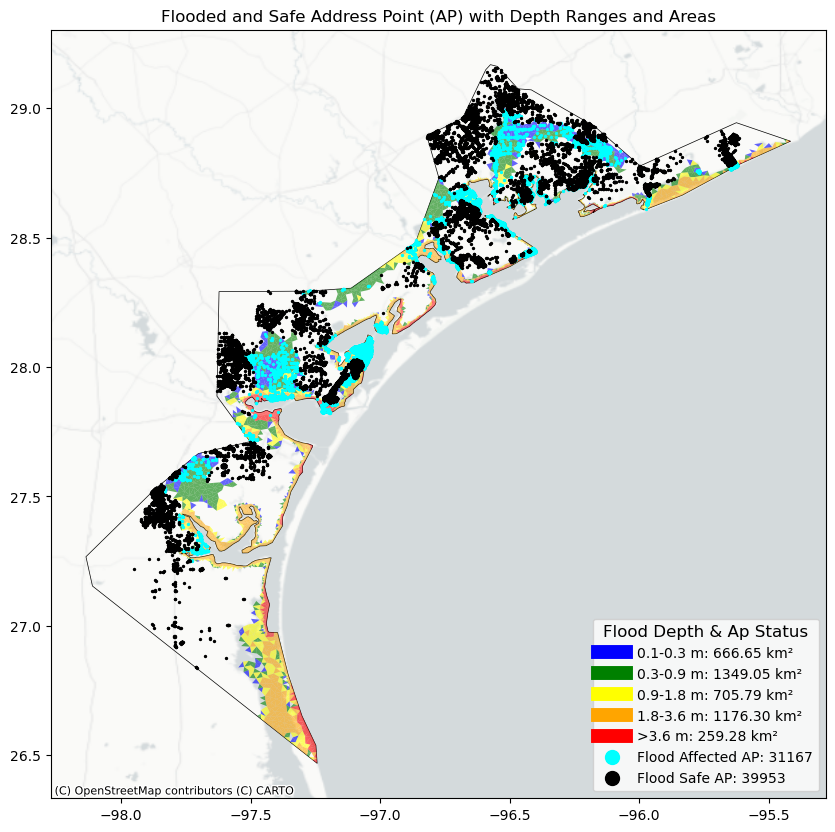

In [9]:
import mikeio
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import contextily as ctx

# Load the DFSU file and extract the desired item
dfsu_file = r"D:\Phd Research\Prototype HD Model\Simulation\Without Reef Scenarios\Climate change condition\5-yr return period storm CC.m21fm - Result Files\5-yr_CC_stat_coupled.dfsu"
ds = mikeio.open(dfsu_file)
data = ds.read(items="Statistical maximum : Total water depth")

# Load the shapefile for the land boundary
shapefile_path = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"
land_boundary = gpd.read_file(shapefile_path)

# Load infrastructure shapefiles and set CRS (EPSG:32614)
infrastructure_paths = [
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48007_ap\shp\stratmap24-addresspoints_48007_aransas_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48057_ap\shp\stratmap24-addresspoints_48057_calhoun_202402.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48239_ap\shp\stratmap24-addresspoints_48239_jackson_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48321_ap\shp\stratmap24-addresspoints_48321_matagorda_202407.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48391_ap\shp\stratmap24-addresspoints_48391_refugio_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48469_ap\shp\stratmap24-addresspoints_48469_victoria_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48061_ap\shp\stratmap24-addresspoints_48061_cameron_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48261_ap\shp\stratmap24-addresspoints_48261_kenedy_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48273_ap\shp\stratmap24-addresspoints_48273_kleberg_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48355_ap\shp\stratmap24-addresspoints_48355_nueces_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48409_ap\shp\stratmap24-addresspoints_48409_sanpatricio_202401.zip",
    r"D:\Phd Research\Critical Infrastructure\Shape file\Address_point\stratmap24-addresspoints_48489_ap\shp\stratmap24-addresspoints_48489_willacy_202403.zip"
]

# Load and reproject each infrastructure shapefile
infrastructures = [gpd.read_file(path).to_crs(32614) for path in infrastructure_paths]

# Perform spatial intersection with land boundary for each infrastructure type
infrastructure_intersections = [gpd.overlay(infra, land_boundary, how='intersection') for infra in infrastructures]

# Extract geometry information from the DFSU file
geometry = ds.geometry
element_table = geometry.element_table
node_coordinates = geometry.node_coordinates

# Get water depth data
water_depth = data[0].to_numpy()

# Define depth ranges and colors
depth_ranges = [(0.1, 0.3), (0.3, 0.9), (0.9, 1.8), (1.8, 3.6), (3.6, np.inf)]
colors = ['blue', 'green', 'yellow', 'orange', 'red']

# Initialize lists for storing polygons and areas by range
flooded_polygons_by_range = []
total_area_by_range = []

# Loop through each depth range to calculate flooded areas and intersections
for low, high in depth_ranges:
    flooded_elements = np.where((water_depth > low) & (water_depth <= high))[1]
    flooded_polygons = [Polygon(node_coordinates[element_table[elem_idx]]) for elem_idx in flooded_elements]
    
    # Create a GeoDataFrame for flooded polygons and clip with land boundary
    flooded_area_gdf = gpd.GeoDataFrame({'geometry': flooded_polygons}, crs="EPSG:32614")
    flooded_area_clipped = gpd.overlay(flooded_area_gdf, land_boundary, how='intersection')
    
    # Calculate and store total area in square kilometers
    total_area_by_range.append(flooded_area_clipped.area.sum() / 1e6)
    flooded_polygons_by_range.append(flooded_area_clipped)

# Function to check if points fall inside flooded areas
def check_flooded(infrastructure, flooded_polygons_by_range):
    flooded, dry = [], []
    for point in infrastructure.itertuples():
        is_flooded = any(flooded_area.contains(point.geometry).any() for flooded_area in flooded_polygons_by_range)
        (flooded if is_flooded else dry).append(point.geometry)
    return flooded, dry

# Check flooded status for each infrastructure
flooded_dry_results = [check_flooded(intersect, flooded_polygons_by_range) for intersect in infrastructure_intersections]
flooded_infrastructures = [gpd.GeoDataFrame(geometry=f, crs="EPSG:32614") for f, _ in flooded_dry_results]
dry_infrastructures = [gpd.GeoDataFrame(geometry=d, crs="EPSG:32614") for _, d in flooded_dry_results]

# Calculate counts of flood-affected and flood-safe CIs
total_flooded_ci = sum(len(f) for f in flooded_infrastructures)
total_safe_ci = sum(len(d) for d in dry_infrastructures)

# Reproject everything to Lat-Long (WGS 84)
land_boundary_latlong = land_boundary.to_crs(epsg=4326)
flooded_polygons_by_range_latlong = [polygons.to_crs(epsg=4326) for polygons in flooded_polygons_by_range]
flooded_infrastructures_latlong = [infra.to_crs(epsg=4326) for infra in flooded_infrastructures]
dry_infrastructures_latlong = [infra.to_crs(epsg=4326) for infra in dry_infrastructures]

# Plotting with Basemap and classification
fig, ax = plt.subplots(figsize=(10, 10))
land_boundary_latlong.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# Plot flooded and dry infrastructures
for flooded, dry in zip(flooded_infrastructures_latlong, dry_infrastructures_latlong):
    flooded.plot(ax=ax, color='cyan', marker='o', markersize=2, zorder=5)
    dry.plot(ax=ax, color='black', marker='o', markersize=2, zorder=5)

# Plot depth ranges with color coding
for polygons, color in zip(flooded_polygons_by_range_latlong, colors):
    if not polygons.empty:
        polygons.plot(ax=ax, color=color, alpha=0.6, edgecolor='none')

# Add basemap
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.CartoDB.PositronNoLabels)

# Create legend labels for depth ranges and flooded areas
legend_labels = [
    f'{low}-{high} m: {area:.2f} km²' if high != np.inf else f'>{low} m: {area:.2f} km²'
    for (low, high), area in zip(depth_ranges, total_area_by_range)
]

# Plot legend for depth ranges with areas
for color, label in zip(colors, legend_labels):
    plt.plot([], [], color=color, label=label, linewidth=10)

# Add legend for critical infrastructures
plt.plot([], [], color='cyan', marker='o', linestyle='None', markersize=10, label=f'Flood Affected AP: {total_flooded_ci}')
plt.plot([], [], color='black', marker='o', linestyle='None', markersize=10, label=f'Flood Safe AP: {total_safe_ci}')

plt.legend(loc='lower right', title='Flood Depth & Ap Status', title_fontsize=12)

plt.title("Flooded and Safe Address Point (AP) with Depth Ranges and Areas")
plt.show()
